## Respuesta de Tarea de Métodos Matemáticos

**Integrantes:**
- Yenny Sánchez Aguilar
- Sebastián Posada Posada
- Andrés Burboa Lizama

### 1. Importar librerías

En esta celda importamos las librerías necesarias para el análisis. Usamos:

- `numpy` para manejar arreglos numéricos y cálculos matriciales
- `matplotlib.pyplot` para generar las gráficas  
- `scipy.integrate.cumulative_trapezoid` para la integración numérica de la ACF

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

### 2. Cargar los datos

Cargamos el archivo `Force_reduce_eq.dat` que contiene las fuerzas temporales registradas durante la simulación MD. 

El archivo tiene 4 columnas: `[tiempo, Fx, Fy, Fz]` donde las fuerzas están en unidades de `(kcal/mol)/Angstrom`.

In [2]:
ruta_data = "Force_reduce_eq.dat" # Ruta de la base de datos, en este caso se encuentra en la raiz del proyecto actual.
data = np.loadtxt(ruta_data) # Cargar el archivo con Numpy
print( data.shape)
print("Primeras filas:\n", data[:3])

(7326574, 4)
Primeras filas:
 [[ 0.00000e+00  1.43621e+00 -2.18156e+00  1.72009e+03]
 [ 1.00000e+00  1.43364e+00 -2.17830e+00  1.72110e+03]
 [ 2.00000e+00  1.41527e+00 -2.18877e+00  1.71580e+03]]


### 3. Eliminar datos de equilibrio

Los primeros 500,000 puntos corresponden al período de equilibración termodinámica de la simulación (500 ps). Estos datos no están en estado estacionario por lo que se descartan para el cálculo de propiedades termodinámicas.

Solo usaremos **Fx** y **Fy** (componentes paralelas a la interfaz) ya que la fricción interfacial se da en el plano XY.

In [3]:
# Obviar los primeros 500000 datos
datos = data[500000:]

print(datos.shape)

# Extraer fuerzas Fx y Fy
Fx_raw = datos[:, 1]
Fy_raw = datos[:, 2]

(6826574, 4)


### 4. Constantes físicas y conversión a unidades SI

Definimos las constantes físicas del sistema y convertimos todas las magnitudes a **unidades SI**:

In [4]:
# Constantes físicas
kB = 1.380649e-23    # Constante de Boltzmann [J/K]
T  = 300.0           # Temperatura [K]
dt = 1e-15           # Paso de tiempo [s]

# Área interfacial
Lx = 19.648e-10      # [m] (1 Angstrom = 1×10^(-10) m)
Ly = 19.143e-10      # [m] (1 Angstrom = 1×10^(-10) m)
A  = Lx * Ly         # [m²]
print(f"Área interfacial: {A:.4e} m^2")

# Factor de conversión: (kcal/mol)/Å → Newton
# 1 kcal = 4184 J | 1 mol = 6.02214076e23 moléculas | 1 Angstrom = 1×10^(-10) m
conv = 4184.0 / (6.02214076e23 * 1e-10)
print(f"Factor conversión fuerza: {conv:.4e} N")

# Convertir fuerzas a Newtons
Fx = Fx_raw * conv   # [N]
Fy = Fy_raw * conv   # [N]

# Prefactor de Green-Kubo
factor_gk = 1.0 / (A * kB * T)
print(f"Factor GK: {factor_gk:.4e}")

Área interfacial: 3.7612e-18 m^2
Factor conversión fuerza: 6.9477e-11 N
Factor GK: 6.4190e+37


### 5. Función de autocorrelación

Implementamos la **función de autocorrelación** con las especificaciones de la tarea en cuestión

In [5]:
def autocorr(x):
    result = np.correlate(x, x, mode='full')
    return result[result.size//2:]

### 6. Cálculo de la ACF

Dividimos la trayectoria en **1365 segmentos independientes** de 5000 puntos cada uno (5 ps).

Para cada segmento:
1. Calculamos las **fluctuaciones**: $\delta F = F - \langle F\rangle$
2. Obtenemos la ACF de esas fluctuaciones  
3. Guardamos todas las ACFs para determinar el promedio de las mismas

In [6]:
N_seg  = 5000               # puntos por intervalo
n_segs = len(Fx) // N_seg   # número de intervalos
print(f"Segmentos: {n_segs} × {N_seg} puntos")

lista_acf_x = []
lista_acf_y = []

for i in range(n_segs):
    ini = i * N_seg
    fin = ini + N_seg

    
    dFx = Fx[ini:fin] - np.mean(Fx[ini:fin])
    dFy = Fy[ini:fin] - np.mean(Fy[ini:fin])

    # Calcular ACF de cada segmento 
    lista_acf_x.append(autocorr(dFx))
    lista_acf_y.append(autocorr(dFy))

# Convertir a array y promediar sobre todos los segmentos
array_acf_x = np.array(lista_acf_x)   # shape: (n_segs, N_seg)
array_acf_y = np.array(lista_acf_y)

acf_x = np.mean(array_acf_x, axis=0)  # shape: (N_seg,)
acf_y = np.mean(array_acf_y, axis=0)

print(acf_x, acf_y)

# Error estándar entre segmentos (para estimar incertidumbre)
err_x = np.std(array_acf_x, axis=0, ddof=1) / np.sqrt(n_segs)
err_y = np.std(array_acf_y, axis=0, ddof=1) / np.sqrt(n_segs)

# Eje de tiempo en femtosegundos
tiempo = np.arange(N_seg)

Segmentos: 1365 × 5000 puntos
[ 4.40383580e-17  4.39323222e-17  4.36367998e-17 ... -3.14804541e-22
 -2.53386465e-22 -1.46513885e-22] [4.45662428e-17 4.44593842e-17 4.41616880e-17 ... 7.69489278e-22
 5.32586446e-22 2.77087911e-22]


### 7. Gráfica de AFC

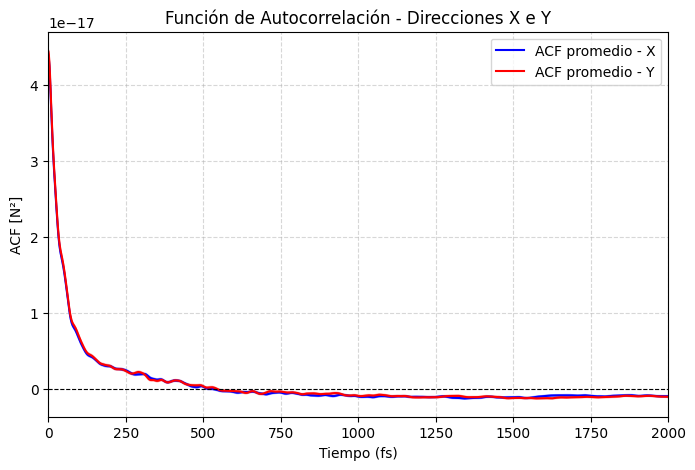

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(tiempo, acf_x, label='ACF promedio - X', color='blue')
plt.plot(tiempo, acf_y, label='ACF promedio - Y', color='red')
plt.fill_between(tiempo, acf_x - err_x, acf_x + err_x, alpha=0.3, color='blue')
plt.fill_between(tiempo, acf_y - err_y, acf_y + err_y, alpha=0.3, color='red')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo (fs)')
plt.ylabel('ACF [N²]')
plt.title('Función de Autocorrelación - Direcciones X e Y')
plt.legend()
plt.xlim(0, 2000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('ACF.png', dpi=150)
plt.show()

### 8. Integración acumulada para obtener λ(t)

Aplicamos la fórmula de **Green-Kubo**:

$$ \lambda = \frac{1}{A k_B T} \int_0^{\tau} \left\langle \delta F(t)\,\delta F(0) \right\rangle \, dt$$

1. `acf_x / N_seg` → convierte suma en promedio temporal
2. `cumulative_trapezoid(..., dx=1)` → integra punto a punto  
3. `* factor_gk * dt` → aplica prefactor y convierte fs→s

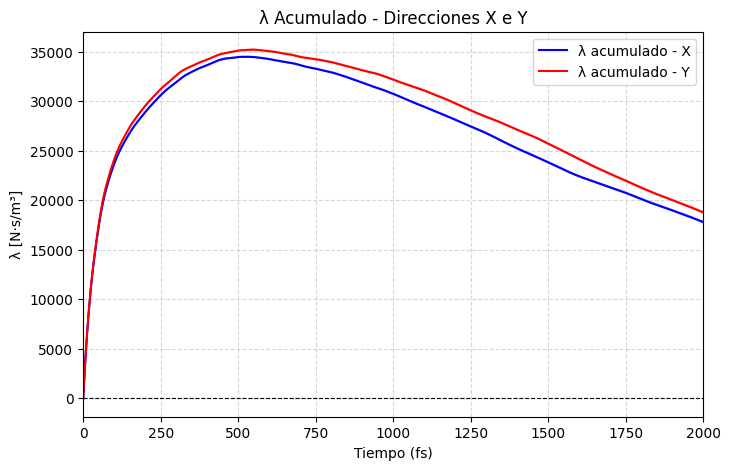

In [8]:
lam_x = cumulative_trapezoid(acf_x / N_seg, dx=1, initial=0) * factor_gk * dt
lam_y = cumulative_trapezoid(acf_y / N_seg, dx=1, initial=0) * factor_gk * dt

# Propagación de incertidumbre
err_lam_x = np.sqrt(cumulative_trapezoid((err_x / N_seg)**2, dx=1, initial=0)) * factor_gk * dt
err_lam_y = np.sqrt(cumulative_trapezoid((err_y / N_seg)**2, dx=1, initial=0)) * factor_gk * dt


plt.figure(figsize=(8, 5))
plt.plot(tiempo, lam_x, label='λ acumulado - X', color='blue')
plt.plot(tiempo, lam_y, label='λ acumulado - Y', color='red')
plt.fill_between(tiempo, lam_x - err_lam_x, lam_x + err_lam_x, alpha=0.3, color='blue')
plt.fill_between(tiempo, lam_y - err_lam_y, lam_y + err_lam_y, alpha=0.3, color='red')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo (fs)')
plt.ylabel('λ [N·s/m³]')
plt.title('λ Acumulado - Direcciones X e Y')
plt.legend()
plt.xlim(0, 2000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('lambda_acumulado.png', dpi=150)
plt.show()